For this project you will visualize time series data using a line chart, bar chart, and box plots. You will use Pandas, Matplotlib, and Seaborn to visualize a dataset containing the number of page views each day on the freeCodeCamp.org forum from 2016-05-09 to 2019-12-03. The data visualizations will help you understand the patterns in visits and identify yearly and monthly growth.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

Use Pandas to import the data from "fcc-forum-pageviews.csv". Set the index to the `date` colum

In [2]:
df = pd.read_csv('fcc-forum-pageviews.csv', index_col='date', parse_dates=True)
df.head()

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933


Clean the data by filtering out days when the page views were in the top 2.5% of the dataset or bottom 2.5% of the dataset.

In [3]:
low = df['value'].quantile(0.025)   # Bottom 2.5%
high = df['value'].quantile(0.975)  # Top 2.5%

df = df.query('value >= @low and value <= @high')

Create a `draw_line_plot` function that uses Matplotlib to draw a line chart similar to "examples/Figure_1.png". The title should be `Daily freeCodeCamp Forum Page Views 5/2016-12/2019`. The label on the x axis should be `Date` and the label on the y axis should be `Page Views`.

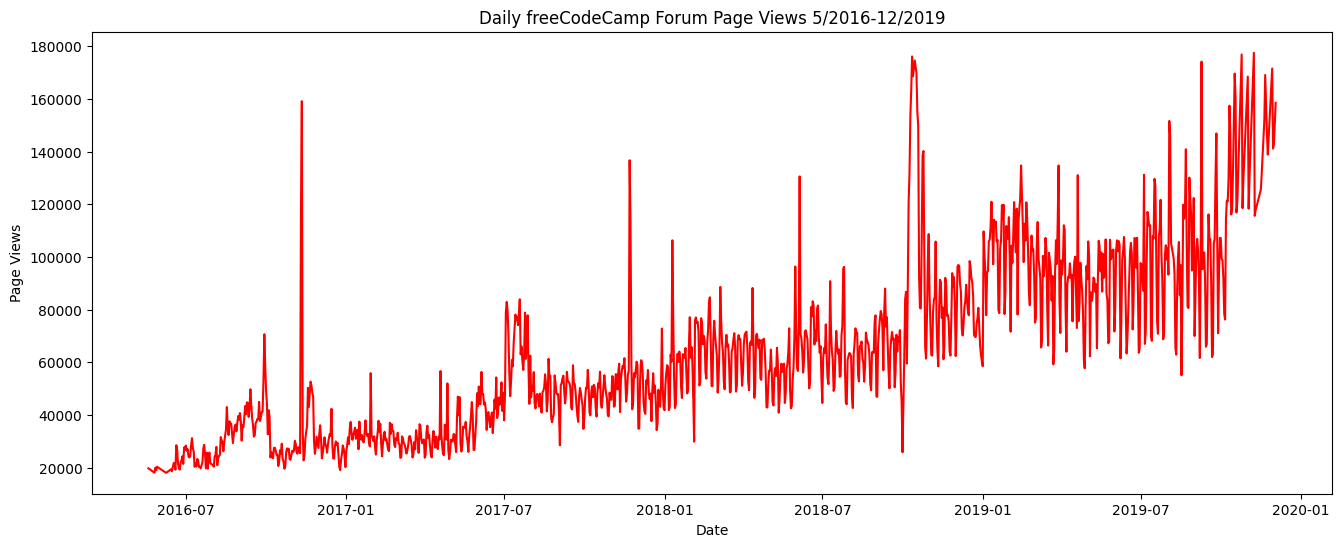

In [50]:
def draw_line_plot(df):
  data = df.copy()
  fig, ax = plt.subplots(figsize=(16, 6))
  ax.plot(data.index, data['value'], color='red')
  ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
  ax.set_xlabel('Date')
  ax.set_ylabel('Page Views')

draw_line_plot(df)

Create a `draw_bar_plot` function that draws a bar chart similar to "examples/Figure_2.png". It should show average daily page views for each month grouped by year. The legend should show month labels and have a title of `Months`. On the chart, the label on the x axis should be `Years` and the label on the y axis should be `Average Page Views`.

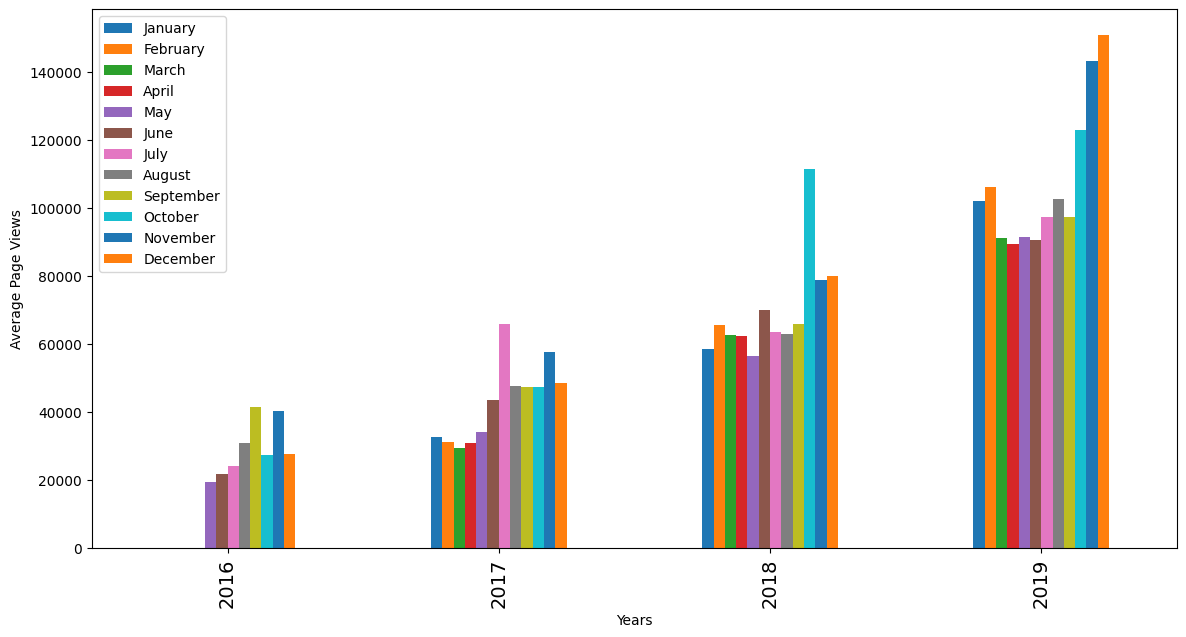

In [142]:
def draw_bar_plot(data):
  df = data.copy()
  df['month'] = df.index.month
  df['Years'] = df.index.year
  df = df.groupby(['Years', 'month'])['value'].mean()
  df = df.unstack()

  fig = df.plot.bar(legend=True, figsize=(14, 7), ylabel='Average Page Views').figure
  plt.legend(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
  plt.xticks(fontsize=14)
  plt.show()

draw_bar_plot(df)

Create a `draw_box_plot` function that uses Seaborn to draw two adjacent box plots similar to "examples/Figure_3.png". These box plots should show how the values are distributed within a given year or month and how it compares over time. The title of the first chart should be `Year-wise Box Plot (Trend)` and the title of the second chart should be `Month-wise Box Plot (Seasonality)`. Make sure the month labels on bottom start at `Jan` and the x and y axis are labeled correctly. The boilerplate includes commands to prepare the data.

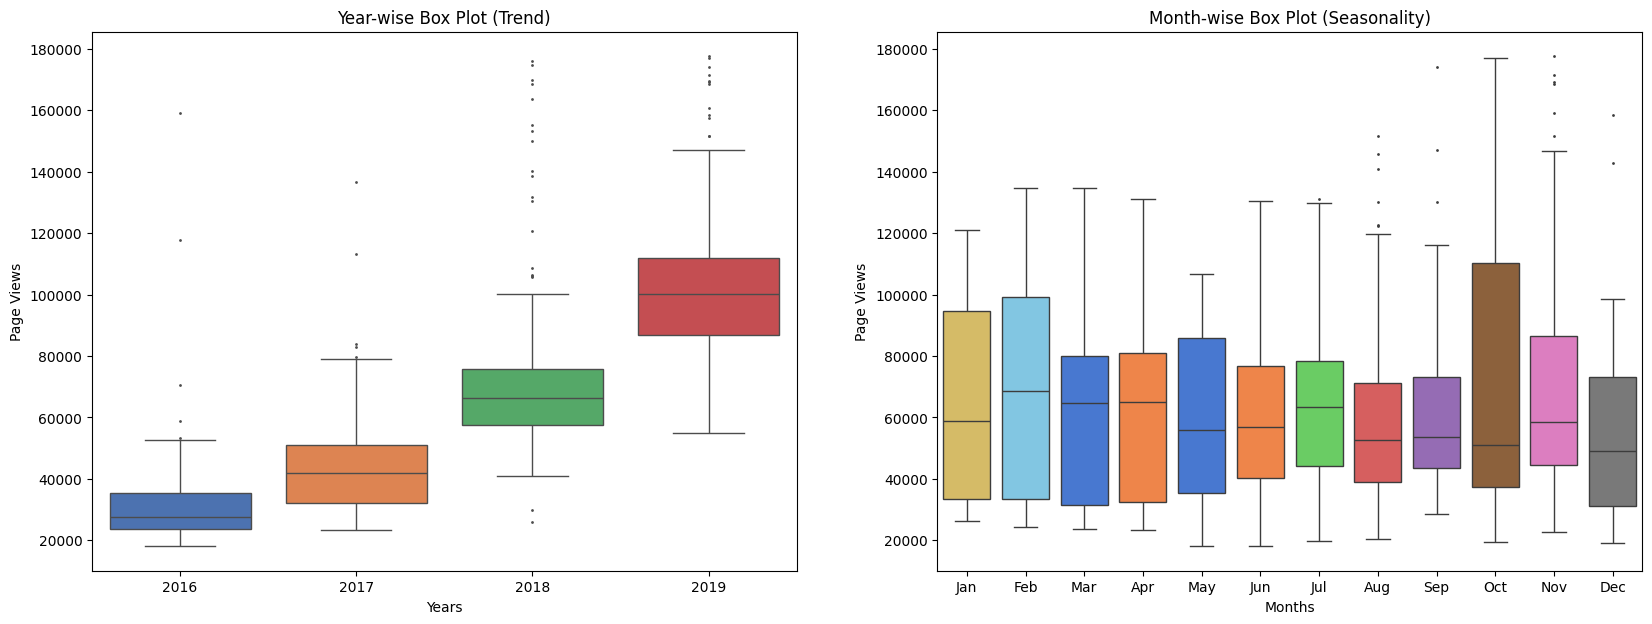

In [144]:
def draw_box_plot(data):
  df_box = data.copy()
  df_box.reset_index(inplace=True)
  df_box['year'] = [d.year for d in df_box.date]
  df_box['month'] = [d.strftime('%b') for d in df_box.date]

  fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=False, sharey=False)
  sns.boxplot(data=df_box, x='year', hue='year', legend=False, y='value', fliersize=1.0, saturation=1.0, ax=axes[0], palette="deep")
  axes[0].set_title('Year-wise Box Plot (Trend)')
  axes[0].set_xlabel('Years')
  axes[0].set_ylabel('Page Views')

  month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

  sns.boxplot(data=df_box, x='month', hue='month', saturation=1.0, fliersize=1.0, order=month_order, y='value', ax=axes[1], palette='muted')
  axes[1].set_title('Month-wise Box Plot (Seasonality)')
  axes[1].set_xlabel('Months')
  axes[1].set_ylabel('Page Views')

draw_box_plot(df)